#スピアマン相関
データを順位に変換してから、その順位が一貫しているかを見る
そのため外れ値に強い、途中で頭打ちするような非線形関係にも適する

In [ ]:
#サンプルデータの作成　ピアソン相関のページと同じ
import numpy as np
import pandas as pd

np.random.seed(0)

n = 50

# 光量
light = np.random.uniform(0, 10, n)

# バイオマス（光量に依存 + ノイズ）
biomass = 2 * light + np.random.normal(0, 2, n)

df = pd.DataFrame({
    "light": light,
    "biomass": biomass
})

In [2]:
from scipy.stats import spearmanr

r,p = spearmanr(df['light'],df['biomass'])
print(r,p)

0.9486194477791116 1.2405764032648358e-25


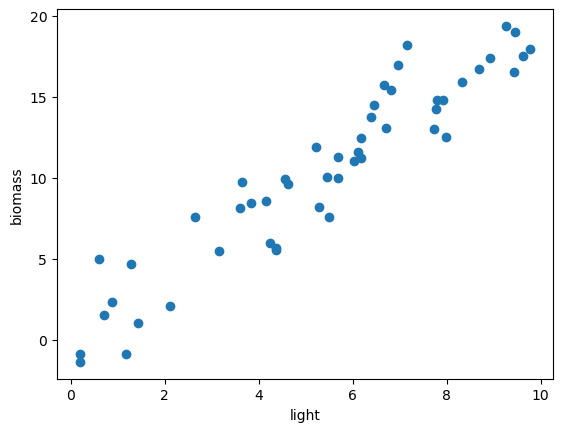

In [ ]:
#可視化　結果はスピアマンと同じ
import matplotlib.pyplot as plt

plt.scatter(df["light"], df["biomass"])
plt.xlabel("light")
plt.ylabel("biomass")
plt.show()

スピアマンのほうが有効な場合
（非線形変化、ノイズがある）

pearson: 0.14785748226478582
spearman: 0.7775750300120047


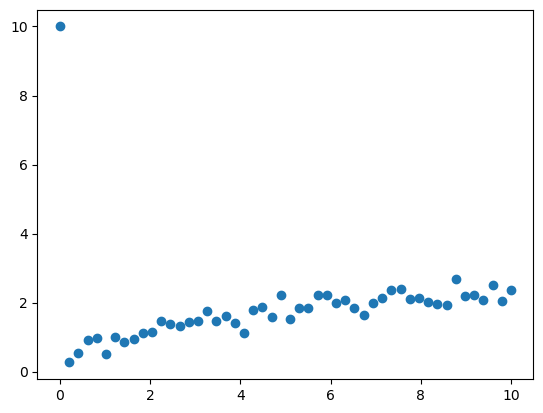

In [4]:
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

np.random.seed(0)

x = np.linspace(0,10,50)# 0~10を５０に分割
y = np.log(x+1) + np.random.normal(0, 0.2, 50)  #ログの曲線にノイズを加える

y[0] = 10 #外れ値を追加

r_p, _ = pearsonr(x, y)
r_s, _ = spearmanr(x, y)

print('pearson:', r_p)
print('spearman:', r_s)

plt.scatter(x,y)
plt.show()

R値はスピアマンのほうが高い→関係をよく表している
生態学において線形な変化はあまり見られない、加えて局所的な特殊環境やヒューマンエラーなどによる外れ値などを考慮するとスピアマンを採用したほうがいいのかも